Mounted at /content/drive
Loading scaled clustering features from:
/content/drive/MyDrive/Fall Semester 2026/AI Resource Capstone - 2277/Capstone Shared Folder/Datasets/Cleaned Data/features_scaled_for_clustering.parquet

k    | Silhouette (Higher=Better)   | Davies-Bouldin (Lower=Better)  | Inertia   
--------------------------------------------------------------------------------
2    | 0.5954                       | 0.9781                         | 1858.94   
3    | 0.6375                       | 0.8112                         | 1208.77   
4    | 0.6670                       | 0.6986                         | 911.58    
5    | 0.6698                       | 0.5679                         | 634.73    
6    | 0.5310                       | 0.7365                         | 516.18    


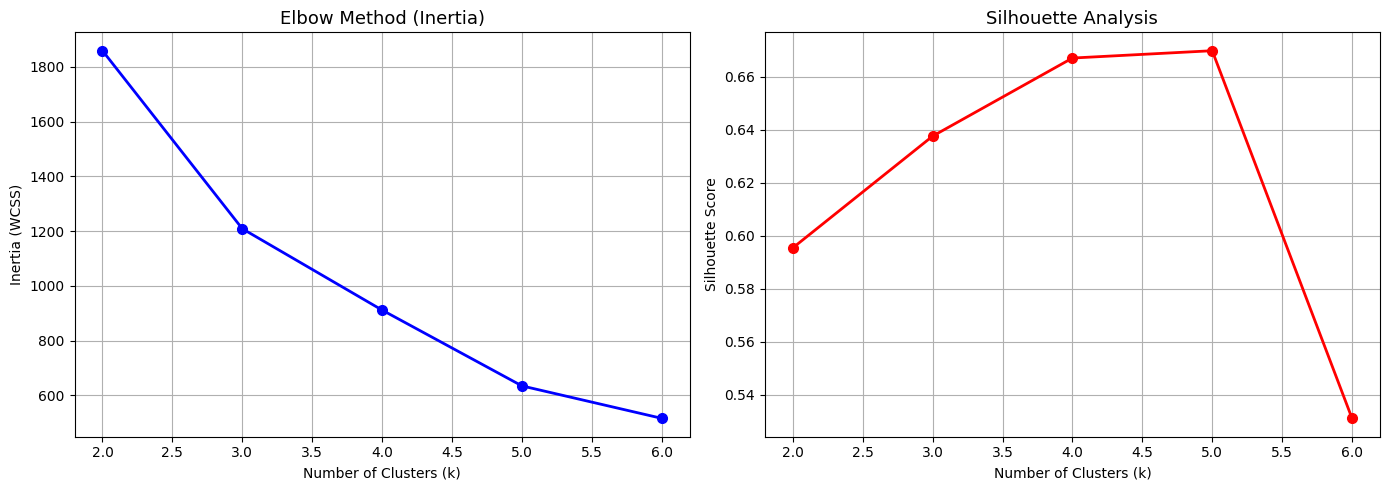

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Path and Load Scaled Feature Store
base_dir = '/content/drive/MyDrive/Fall Semester 2026/AI Resource Capstone - 2277/Capstone Shared Folder/Datasets/Cleaned Data'
file_path = os.path.join(base_dir, 'features_scaled_for_clustering.parquet')

print(f"Loading scaled clustering features from:\n{file_path}\n")
df_scaled = pd.read_parquet(file_path)

# 3. Separate Primary Key from Clustering Features
X_cluster = df_scaled.drop(columns=['zip_code'])

# 4. Evaluate k = 2 through 6
k_range = range(2, 7)
inertia_values = []
silhouette_scores = []
db_scores = []

print(f"{'k':<4} | {'Silhouette (Higher=Better)':<28} | {'Davies-Bouldin (Lower=Better)':<30} | {'Inertia':<10}")
print("-" * 80)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)

    sil = silhouette_score(X_cluster, labels)
    db = davies_bouldin_score(X_cluster, labels)

    inertia_values.append(km.inertia_)
    silhouette_scores.append(sil)
    db_scores.append(db)

    print(f"{k:<4} | {sil:<28.4f} | {db:<30.4f} | {km.inertia_:<10.2f}")

# 5. Plot Elbow & Silhouette Evaluation Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=7)
ax1.set_title('Elbow Method (Inertia)', fontsize=13)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.grid(True)

ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=7)
ax2.set_title('Silhouette Analysis', fontsize=13)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# 1. Paths
base_dir = '/content/drive/MyDrive/Fall Semester 2026/AI Resource Capstone - 2277/Capstone Shared Folder/Datasets/Cleaned Data'
scaled_parquet = os.path.join(base_dir, 'features_scaled_for_clustering.parquet')
master_parquet = os.path.join(base_dir, 'master_living_costs_3counties.parquet')

# 2. Load Datasets
df_scaled = pd.read_parquet(scaled_parquet)
df_master = pd.read_parquet(master_parquet)

df_scaled['zip_code'] = df_scaled['zip_code'].astype(str).str.zfill(5)
df_master['zip_code'] = df_master['zip_code'].astype(str).str.zfill(5)

# 3. Fit Final K-Means Model (k = 5)
X_cluster = df_scaled.drop(columns=['zip_code'])
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
df_master['cost_risk_cluster'] = kmeans.fit_predict(X_cluster)

# 4. Profile the Clusters (Unscaled Real Dollar & Percentage Means)
profile_cols = [
    'cost_risk_cluster',
    'pct_area_100yr_flood',
    'pct_area_coastal_surge',
    'nfip_total_claims',
    'water_mud_flag',
    'water_base_monthly_fee',
    'water_rate_per_1k_gal',
    'elec_base_monthly_fee',
    'elec_delivery_rate_per_kwh',
    'twia_mandatory'
]

cluster_profiles = df_master[profile_cols].groupby('cost_risk_cluster').agg({
    'pct_area_100yr_flood': 'mean',
    'pct_area_coastal_surge': 'mean',
    'nfip_total_claims': 'mean',
    'water_mud_flag': 'mean',
    'water_base_monthly_fee': 'mean',
    'water_rate_per_1k_gal': 'mean',
    'elec_base_monthly_fee': 'mean',
    'elec_delivery_rate_per_kwh': 'mean',
    'twia_mandatory': 'mean',
    'cost_risk_cluster': 'count'
}).rename(columns={'cost_risk_cluster': 'zip_count'}).reset_index()

print("--- 5-Cluster Macro Archetype Summary (Real-World Means) ---")
display(cluster_profiles)

print("\n--- Distribution of ZIPs across Counties and Clusters ---")
print(pd.crosstab(df_master['county_name'], df_master['cost_risk_cluster'], margins=True))

# 5. Save Model-Ready Deliverables for Web Deployment
output_parquet = os.path.join(base_dir, 'master_living_costs_clustered.parquet')
output_csv = os.path.join(base_dir, 'master_living_costs_clustered.csv')

df_master.to_parquet(output_parquet, index=False)
df_master.to_csv(output_csv, index=False)

print(f"\nSaved labeled dataset to:")
print(f" -> {output_parquet}")
print(f" -> {output_csv}")

--- 5-Cluster Macro Archetype Summary (Real-World Means) ---


,cost_risk_cluster,pct_area_100yr_flood,pct_area_coastal_surge,nfip_total_claims,water_mud_flag,water_base_monthly_fee,water_rate_per_1k_gal,elec_base_monthly_fee,elec_delivery_rate_per_kwh,twia_mandatory,zip_count
0,0,1.725389,0.0,662.989637,0.000000,16.8,6.450000,4.390000,0.038100,0.0,193
1,1,1.000000,0.0,4.000000,0.000000,16.8,6.450000,4.390000,0.038100,0.0,1
2,2,42.000000,18.5,3996.230769,0.769231,25.8,8.026923,7.051538,0.044331,1.0,13
3,3,4.137931,0.0,629.275862,1.000000,28.5,8.500000,4.390000,0.038100,0.0,58
4,4,5.000000,0.0,1434.142857,1.000000,28.5,8.500000,7.850000,0.046200,1.0,14



--- Distribution of ZIPs across Counties and Clusters ---
cost_risk_cluster    0  1   2   3   4  All
county_name                               
Fort Bend            0  0   0  31   0   31
Galveston            0  0  10   0  14   24
Harris             193  1   3  27   0  224
All                193  1  13  58  14  279

Saved labeled dataset to:
 -> /content/drive/MyDrive/Fall Semester 2026/AI Resource Capstone - 2277/Capstone Shared Folder/Datasets/Cleaned Data/master_living_costs_clustered.parquet
 -> /content/drive/MyDrive/Fall Semester 2026/AI Resource Capstone - 2277/Capstone Shared Folder/Datasets/Cleaned Data/master_living_costs_clustered.csv


In [ ]:
import pandas as pd

df = pd.read_parquet('/content/drive/MyDrive/Fall Semester 2026/AI Resource Capstone - 2277/Capstone Shared Folder/Datasets/Cleaned Data/master_living_costs_clustered.parquet')

print("ZIP Count per Cluster:")
print(df['cost_risk_cluster'].value_counts().sort_index())

print("\nMean Profiles per Cluster:")
cols_to_check = ['pct_area_100yr_flood', 'pct_area_coastal_surge', 'water_mud_flag', 'twia_mandatory', 'elec_base_monthly_fee']
print(df.groupby('cost_risk_cluster')[cols_to_check].mean().round(2))

ZIP Count per Cluster:
cost_risk_cluster
0    193
1      1
2     13
3     58
4     14
Name: count, dtype: int64

Mean Profiles per Cluster:
                   pct_area_100yr_flood  pct_area_coastal_surge  \
cost_risk_cluster                                                 
0                                  1.73                     0.0   
1                                  1.00                     0.0   
2                                 42.00                    18.5   
3                                  4.14                     0.0   
4                                  5.00                     0.0   

                   water_mud_flag  twia_mandatory  elec_base_monthly_fee  
cost_risk_cluster                                                         
0                            0.00             0.0                   4.39  
1                            0.00             0.0                   4.39  
2                            0.77             1.0                   7.05  
3              

In [ ]:
import os
import pandas as pd
from sklearn.cluster import KMeans

base_dir = '/content/drive/MyDrive/Fall Semester 2026/AI Resource Capstone - 2277/Capstone Shared Folder/Datasets/Cleaned Data'
df_master = pd.read_parquet(os.path.join(base_dir, 'master_living_costs_clustered.parquet'))
df_scaled = pd.read_parquet(os.path.join(base_dir, 'features_scaled_for_clustering.parquet'))

# 1. Identify the single outlier ZIP in Cluster 1
outlier_zip = df_master[df_master['cost_risk_cluster'] == 1]
print("--- Isolated ZIP in Cluster 1 ---")
display(outlier_zip[['zip_code', 'county_name', 'est_flood_risk_tier', 'water_service_type', 'twia_mandatory']])

# 2. Fit k=4 to compare cluster distributions
X_cluster = df_scaled.drop(columns=['zip_code'])
km4 = KMeans(n_clusters=4, random_state=42, n_init=20)
df_master['cluster_k4'] = km4.fit_predict(X_cluster)

print("\n--- Distribution Comparison ---")
print("k = 5 Cluster Counts:\n", df_master['cost_risk_cluster'].value_counts().sort_index())
print("\nk = 4 Cluster Counts:\n", df_master['cluster_k4'].value_counts().sort_index())

print("\nk = 4 Mean Profiles:")
cols_to_check = ['pct_area_100yr_flood', 'pct_area_coastal_surge', 'water_mud_flag', 'twia_mandatory', 'elec_base_monthly_fee']
display(df_master.groupby('cluster_k4')[cols_to_check].mean().round(2))

--- Isolated ZIP in Cluster 1 ---


,zip_code,county_name,est_flood_risk_tier,water_service_type,twia_mandatory
113,77225,Harris,X,Municipal_CityOfHouston,0



--- Distribution Comparison ---
k = 5 Cluster Counts:
 cost_risk_cluster
0    193
1      1
2     13
3     58
4     14
Name: count, dtype: int64

k = 4 Cluster Counts:
 cluster_k4
0    193
1     14
2     59
3     13
Name: count, dtype: int64

k = 4 Mean Profiles:


,pct_area_100yr_flood,pct_area_coastal_surge,water_mud_flag,twia_mandatory,elec_base_monthly_fee
cluster_k4,,,,,
0,1.73,0.0,0.00,0.0,4.39
1,5.00,0.0,1.00,1.0,7.85
2,4.08,0.0,0.98,0.0,4.39
3,42.00,18.5,0.77,1.0,7.05


In [ ]:
import os
import pandas as pd
from sklearn.cluster import KMeans

base_dir = '/content/drive/MyDrive/Fall Semester 2026/AI Resource Capstone - 2277/Capstone Shared Folder/Datasets/Cleaned Data'
scaled_parquet = os.path.join(base_dir, 'features_scaled_for_clustering.parquet')
master_parquet = os.path.join(base_dir, 'master_living_costs_3counties.parquet')

df_scaled = pd.read_parquet(scaled_parquet)
df_master = pd.read_parquet(master_parquet)

df_scaled['zip_code'] = df_scaled['zip_code'].astype(str).str.zfill(5)
df_master['zip_code'] = df_master['zip_code'].astype(str).str.zfill(5)

# 1. Fit final k=4 model
X_cluster = df_scaled.drop(columns=['zip_code'])
km = KMeans(n_clusters=4, random_state=42, n_init=20)
df_master['cost_risk_cluster'] = km.fit_predict(X_cluster)

# 2. Map Archetype Human-Readable Labels
archetype_map = {
    0: 'Urban Core / Municipal Stable',
    1: 'Galveston Mainland / Coastal Utility Corridor',
    2: 'Suburban MUD Growth Corridor',
    3: 'High-Hazard Coastal Surge & Floodplain'
}
df_master['cluster_archetype_name'] = df_master['cost_risk_cluster'].map(archetype_map)

# 3. Overwrite with Final Cleaned Outputs
out_parquet = os.path.join(base_dir, 'master_living_costs_clustered.parquet')
out_csv = os.path.join(base_dir, 'master_living_costs_clustered.csv')

df_master.to_parquet(out_parquet, index=False)
df_master.to_csv(out_csv, index=False)

print("Final Deliverable Saved Successfully with k=4 Archetypes!")
print(f" -> {out_parquet}")
print(f" -> {out_csv}")
df_master[['zip_code', 'county_name', 'cost_risk_cluster', 'cluster_archetype_name']].head(10)

Final Deliverable Saved Successfully with k=4 Archetypes!
 -> /content/drive/MyDrive/Fall Semester 2026/AI Resource Capstone - 2277/Capstone Shared Folder/Datasets/Cleaned Data/master_living_costs_clustered.parquet
 -> /content/drive/MyDrive/Fall Semester 2026/AI Resource Capstone - 2277/Capstone Shared Folder/Datasets/Cleaned Data/master_living_costs_clustered.csv


,zip_code,county_name,cost_risk_cluster,cluster_archetype_name
0,77001,Harris,0,Urban Core / Municipal Stable
1,77002,Harris,0,Urban Core / Municipal Stable
2,77003,Harris,0,Urban Core / Municipal Stable
3,77004,Harris,0,Urban Core / Municipal Stable
4,77005,Harris,0,Urban Core / Municipal Stable
5,77006,Harris,0,Urban Core / Municipal Stable
6,77007,Harris,0,Urban Core / Municipal Stable
7,77008,Harris,0,Urban Core / Municipal Stable
8,77009,Harris,0,Urban Core / Municipal Stable
9,77010,Harris,0,Urban Core / Municipal Stable
